# R(2+1)D-18 Training on Google Colab

Self-contained notebook — trains the pretrained R(2+1)D-18 on the video clips
using Colab's free GPU.
**Before running:** make sure the runtime is set to GPU
(Runtime → Change runtime type → Hardware accelerator → GPU → Save).

## Step 1 — Check GPU

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — set Runtime to GPU!")

CUDA available: True
GPU: Tesla T4


## Step 2 — Mount Google Drive

This lets Colab read the clips you uploaded to your Drive.
A popup will ask you to authorize — click your account and allow.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 3 — Unzip the clips

Assumes you uploaded `processed.zip` to the root of your Drive ("My Drive").
The zip should contain:
```
processed/train/*.npy + _metadata.csv
processed/test/*.npy  + _metadata.csv
```
Adjust ZIP_PATH if you put it in a subfolder.

In [3]:
import zipfile, os

ZIP_PATH = "/content/drive/MyDrive/processed.zip"
EXTRACT_TO = "/content/data"

os.makedirs(EXTRACT_TO, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)

# Find the metadata files (handles either data/processed/... or processed/...)
import glob
train_meta = glob.glob(f"{EXTRACT_TO}/**/train/_metadata.csv", recursive=True)[0]
test_meta = glob.glob(f"{EXTRACT_TO}/**/test/_metadata.csv", recursive=True)[0]
print("Train metadata:", train_meta)
print("Test metadata: ", test_meta)

Train metadata: /content/data/processed/train/_metadata.csv
Test metadata:  /content/data/processed/test/_metadata.csv


## Step 4 — Fix clip paths in the metadata

The `npy_path` column was written on your Mac (`../data/processed/...`).
We rewrite it to point at the unzipped location in Colab.

In [4]:
import pandas as pd
from pathlib import Path

def fix_metadata_paths(meta_csv):
    meta = pd.read_csv(meta_csv)
    base = Path(meta_csv).parent   # .../train or .../test
    # Rebuild each path from the filename, pointing into the unzipped folder
    meta['npy_path'] = meta['npy_path'].apply(
        lambda p: str(base / Path(p).name)
    )
    # Sanity check first file exists
    assert Path(meta.iloc[0]['npy_path']).exists(), \
        f"Clip not found: {meta.iloc[0]['npy_path']}"
    meta.to_csv(meta_csv, index=False)
    return meta

train_df_meta = fix_metadata_paths(train_meta)
test_df_meta = fix_metadata_paths(test_meta)
print(f"Train clips: {len(train_df_meta)}  Test clips: {len(test_df_meta)}")

Train clips: 3117  Test clips: 1101


## Step 5 — Dataset class (inline)

In [5]:
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader, Subset

IMAGENET_MEAN = np.array([0.43216, 0.394666, 0.37645], dtype=np.float32)
IMAGENET_STD = np.array([0.22803, 0.22145, 0.216989], dtype=np.float32)
NUM_CLASSES = 13

CLASS_NAMES = [
    "Point-1f", "Point-2f", "Click-1f", "Click-2f",
    "Throw-up", "Throw-down", "Throw-left", "Throw-right",
    "Open-twice", "DblClick-1f", "DblClick-2f", "Zoom-in", "Zoom-out"
]


class GestureClipDataset(Dataset):
    def __init__(self, metadata_csv, train=False, crop_size=112, resize_to=128):
        self.meta = pd.read_csv(metadata_csv)
        self.train = train
        self.crop_size = crop_size
        self.resize_to = resize_to

    def __len__(self):
        return len(self.meta)

    def _augment(self, clip):
        T, H, W, C = clip.shape
        cs = self.crop_size
        if self.train:
            rs = self.resize_to
            clip = np.stack([cv2.resize(f, (rs, rs)) for f in clip])
            top = np.random.randint(0, rs - cs + 1)
            left = np.random.randint(0, rs - cs + 1)
            clip = clip[:, top:top+cs, left:left+cs, :]
            if np.random.rand() < 0.5:
                clip = clip[:, :, ::-1, :]
        else:
            clip = np.stack([cv2.resize(f, (cs, cs)) for f in clip])
        return np.ascontiguousarray(clip)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        clip = np.load(row['npy_path'])
        clip = self._augment(clip)
        clip = clip.astype(np.float32) / 255.0
        clip = (clip - IMAGENET_MEAN) / IMAGENET_STD
        clip = np.transpose(clip, (3, 0, 1, 2))   # (C,T,H,W)
        return torch.from_numpy(clip).float(), int(row['label'])


def compute_class_weights(metadata_csv, num_classes=NUM_CLASSES):
    meta = pd.read_csv(metadata_csv)
    counts = meta['label'].value_counts().sort_index()
    freq = np.ones(num_classes, dtype=np.float32)
    for label, c in counts.items():
        freq[int(label)] = c
    weights = freq.sum() / (num_classes * freq)
    return torch.from_numpy(weights.astype(np.float32))

## Step 6 — Build the model (pretrained R(2+1)D-18)

In [6]:
import torch.nn as nn
import torchvision.models.video as video_models

def build_r2plus1d(num_classes=NUM_CLASSES, dropout=0.5):
    try:
        weights = video_models.R2Plus1D_18_Weights.KINETICS400_V1
        model = video_models.r2plus1d_18(weights=weights)
    except AttributeError:
        model = video_models.r2plus1d_18(pretrained=True)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))
    return model

device = torch.device("cuda")
model = build_r2plus1d().to(device)

total = sum(p.numel() for p in model.parameters())
print(f"R(2+1)D-18: {total:,} parameters")

Downloading: "https://download.pytorch.org/models/r2plus1d_18-91a641e6.pth" to /root/.cache/torch/hub/checkpoints/r2plus1d_18-91a641e6.pth


100%|██████████| 120M/120M [00:00<00:00, 189MB/s]


R(2+1)D-18: 31,306,794 parameters


## Step 7 — Data loaders

In [7]:
from sklearn.model_selection import train_test_split

# Stratified val split from train
meta_all = pd.read_csv(train_meta)
tr_idx, va_idx = train_test_split(
    np.arange(len(meta_all)), test_size=0.15,
    stratify=meta_all['label'], random_state=42
)

full_train = GestureClipDataset(train_meta, train=True)
full_train_noaug = GestureClipDataset(train_meta, train=False)
test_ds = GestureClipDataset(test_meta, train=False)

train_ds = Subset(full_train, tr_idx)
val_ds = Subset(full_train_noaug, va_idx)

BATCH_SIZE = 16   # GPU handles bigger batches than MPS
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape)   # (16,3,16,112,112)

Train: 2649  Val: 468  Test: 1101
Batch shape: torch.Size([16, 3, 16, 112, 112])


# Step 8b — Learning rate sweep for R(2+1)D-18

In [9]:
import time
import matplotlib.pyplot as plt

# Pretrained model -> low learning rates only (high lr destroys pretrained features)
LR_GRID = [1e-3, 3e-4, 1e-4, 3e-5]
SWEEP_EPOCHS = 10

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if is_train:
                optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total


sweep_histories = {}   # lr -> list of val accuracies

for lr in LR_GRID:
    print(f"\n{'='*55}\n  Learning rate: {lr}\n{'='*55}")
    torch.manual_seed(42)
    model_sweep = build_r2plus1d(num_classes=NUM_CLASSES).to(device)

    class_weights = compute_class_weights(train_meta).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model_sweep.parameters(), lr=lr, weight_decay=1e-5)

    val_accs = []
    for epoch in range(1, SWEEP_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model_sweep, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model_sweep, val_loader, criterion, None)
        val_accs.append(va_acc)
        print(f"  epoch {epoch:2d}/{SWEEP_EPOCHS} | train acc {tr_acc:.3f} | "
              f"val acc {va_acc:.3f} | {time.time()-t0:.0f}s")
    sweep_histories[lr] = val_accs


  Learning rate: 0.001
  epoch  1/10 | train acc 0.245 | val acc 0.274 | 366s
  epoch  2/10 | train acc 0.355 | val acc 0.299 | 371s
  epoch  3/10 | train acc 0.388 | val acc 0.244 | 371s
  epoch  4/10 | train acc 0.445 | val acc 0.436 | 371s
  epoch  5/10 | train acc 0.485 | val acc 0.491 | 371s
  epoch  6/10 | train acc 0.496 | val acc 0.491 | 371s
  epoch  7/10 | train acc 0.536 | val acc 0.509 | 371s
  epoch  8/10 | train acc 0.565 | val acc 0.547 | 371s
  epoch  9/10 | train acc 0.604 | val acc 0.498 | 371s
  epoch 10/10 | train acc 0.652 | val acc 0.509 | 371s

  Learning rate: 0.0003
  epoch  1/10 | train acc 0.467 | val acc 0.585 | 372s
  epoch  2/10 | train acc 0.677 | val acc 0.566 | 372s
  epoch  3/10 | train acc 0.779 | val acc 0.720 | 372s
  epoch  4/10 | train acc 0.823 | val acc 0.818 | 373s
  epoch  5/10 | train acc 0.810 | val acc 0.803 | 372s
  epoch  6/10 | train acc 0.863 | val acc 0.846 | 372s
  epoch  7/10 | train acc 0.883 | val acc 0.671 | 372s
  epoch  8/10 | 

### Plot 1: val accuracy curves

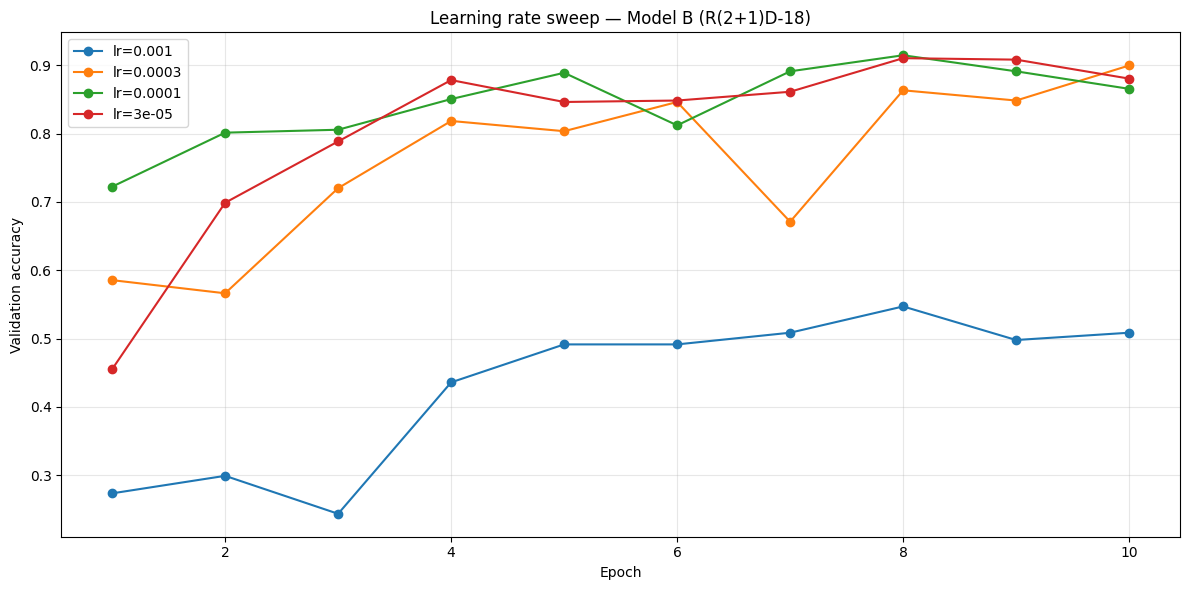

In [10]:
plt.figure(figsize=(12, 6))
for lr, accs in sweep_histories.items():
    plt.plot(range(1, len(accs) + 1), accs, marker='o', label=f"lr={lr}")
plt.xlabel('Epoch'); plt.ylabel('Validation accuracy')
plt.title('Learning rate sweep — Model B (R(2+1)D-18)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/lr_sweep_curves_modelB.png", dpi=150, bbox_inches='tight')
plt.show()

### Plot 2: best val acc vs lr

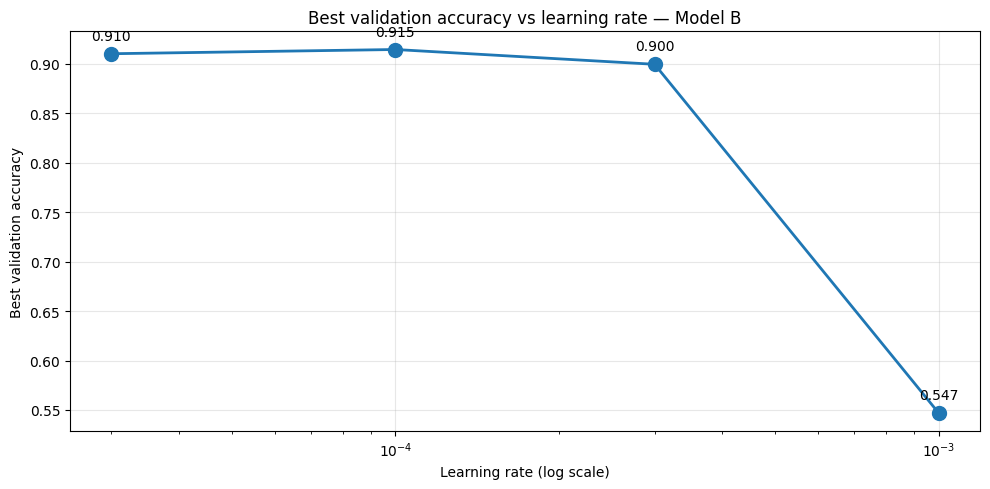

In [11]:
best_per_lr = {lr: max(accs) for lr, accs in sweep_histories.items()}
plt.figure(figsize=(10, 5))
plt.semilogx(list(best_per_lr.keys()), list(best_per_lr.values()),
             marker='o', markersize=10, linewidth=2)
for lr, v in best_per_lr.items():
    plt.annotate(f"{v:.3f}", (lr, v), textcoords="offset points", xytext=(0, 10), ha='center')
plt.xlabel('Learning rate (log scale)'); plt.ylabel('Best validation accuracy')
plt.title('Best validation accuracy vs learning rate — Model B')
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/lr_sweep_best_modelB.png", dpi=150, bbox_inches='tight')
plt.show()


In [12]:
best_lr_b = max(best_per_lr, key=best_per_lr.get)
print(f"\nBest learning rate: {best_lr_b}  (val acc {best_per_lr[best_lr_b]:.3f})")
for lr, v in sorted(best_per_lr.items(), key=lambda x: -x[1]):
    print(f"  lr={lr:<8} best val acc {v:.3f}")


Best learning rate: 0.0001  (val acc 0.915)
  lr=0.0001   best val acc 0.915
  lr=3e-05    best val acc 0.910
  lr=0.0003   best val acc 0.900
  lr=0.001    best val acc 0.547


In [13]:
# Copy sweep plots to Drive so you keep them
import shutil, os
os.makedirs("/content/drive/MyDrive/r2plus1d_results", exist_ok=True)
shutil.copy("/content/lr_sweep_curves_modelB.png", "/content/drive/MyDrive/r2plus1d_results")
shutil.copy("/content/lr_sweep_best_modelB.png", "/content/drive/MyDrive/r2plus1d_results")
print("Sweep plots saved to Drive.")

Sweep plots saved to Drive.


## Step 8 — Train

In [15]:
import time

class_weights = compute_class_weights(train_meta).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if is_train:
                optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total


EPOCHS = 30
PATIENCE = 8
best_val = float('inf')
no_improve = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = run_epoch(model, val_loader, criterion, None)
    scheduler.step(va_loss)

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss); history['val_acc'].append(va_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f} | {time.time()-t0:.0f}s")

    if va_loss < best_val:
        best_val = va_loss
        no_improve = 0
        torch.save(model.state_dict(), "/content/best_r2plus1d.pth")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(torch.load("/content/best_r2plus1d.pth"))
print("Training done.")

Epoch  1/30 | train loss 1.964 acc 0.392 | val loss 1.116 acc 0.662 | 373s
Epoch  2/30 | train loss 0.841 acc 0.759 | val loss 0.700 acc 0.803 | 372s
Epoch  3/30 | train loss 0.586 acc 0.838 | val loss 0.454 acc 0.874 | 372s
Epoch  4/30 | train loss 0.411 acc 0.880 | val loss 0.502 acc 0.812 | 371s
Epoch  5/30 | train loss 0.358 acc 0.897 | val loss 0.544 acc 0.835 | 372s
Epoch  6/30 | train loss 0.299 acc 0.918 | val loss 0.490 acc 0.880 | 371s
Epoch  7/30 | train loss 0.241 acc 0.936 | val loss 0.560 acc 0.842 | 371s
Epoch  8/30 | train loss 0.209 acc 0.939 | val loss 0.512 acc 0.874 | 372s
Epoch  9/30 | train loss 0.158 acc 0.956 | val loss 0.386 acc 0.908 | 371s
Epoch 10/30 | train loss 0.094 acc 0.976 | val loss 0.367 acc 0.917 | 372s
Epoch 11/30 | train loss 0.092 acc 0.973 | val loss 0.596 acc 0.876 | 373s
Epoch 12/30 | train loss 0.076 acc 0.980 | val loss 0.409 acc 0.912 | 371s
Epoch 13/30 | train loss 0.039 acc 0.990 | val loss 0.448 acc 0.917 | 372s
Epoch 14/30 | train loss 

## Step 9 — Plot training curves

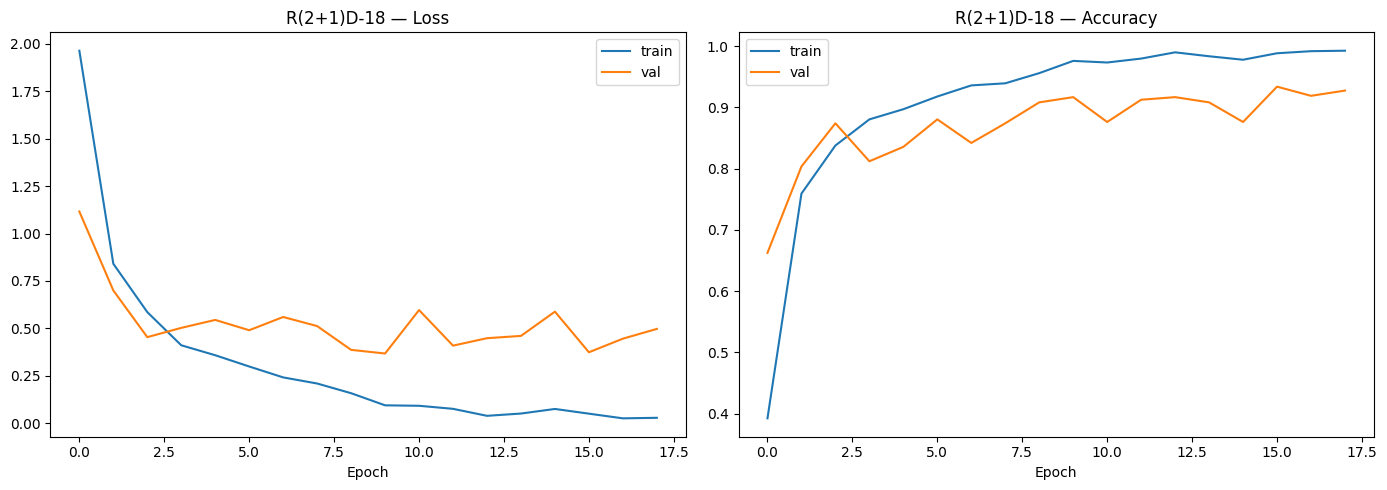

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('R(2+1)D-18 — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('R(2+1)D-18 — Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig("/content/history_r2plus1d.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Evaluate on the test set

Accuracy:      0.9083
F1 (weighted): 0.9090
F1 (macro):    0.8699
Top-3 acc:     0.9837
Top-5 acc:     0.9909

               precision    recall  f1-score   support

    Point-1f       0.98      0.96      0.97       265
    Point-2f       0.98      0.96      0.97       264
    Click-1f       0.79      0.85      0.81        52
    Click-2f       0.69      0.81      0.74        52
    Throw-up       0.98      0.85      0.91        52
  Throw-down       0.83      1.00      0.90        52
  Throw-left       1.00      0.88      0.94        52
 Throw-right       0.84      0.98      0.90        52
  Open-twice       0.91      0.92      0.91        52
 DblClick-1f       0.88      0.83      0.85        52
 DblClick-2f       0.78      0.73      0.75        52
     Zoom-in       0.77      0.90      0.83        52
    Zoom-out       0.93      0.71      0.80        52

    accuracy                           0.91      1101
   macro avg       0.87      0.88      0.87      1101
weighted avg       0.9

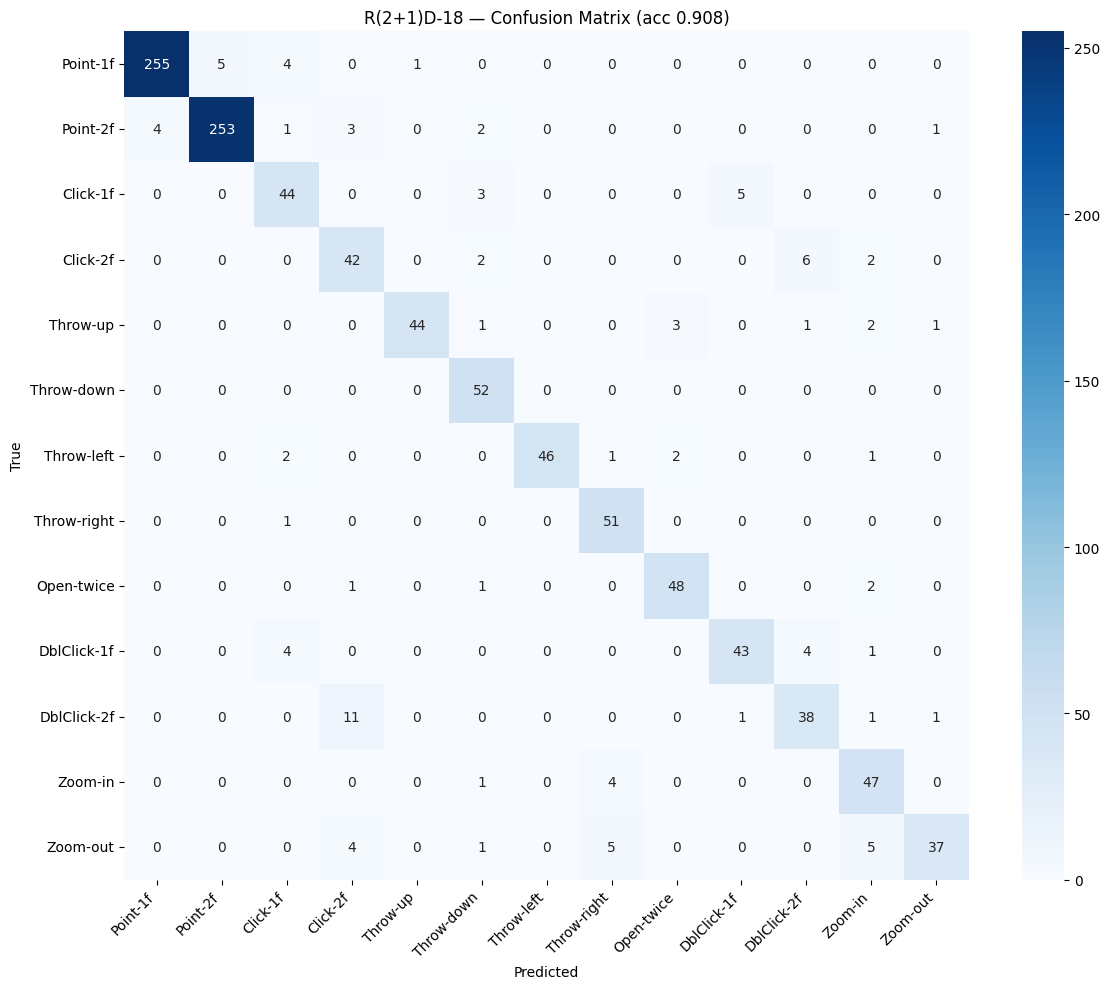

In [17]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, top_k_accuracy_score)
import seaborn as sns

@torch.no_grad()
def predict(model, loader):
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    for x, y in loader:
        x = x.to(device)
        prob = torch.softmax(model(x), dim=1).cpu().numpy()
        all_prob.append(prob)
        all_pred.append(prob.argmax(1))
        all_true.append(y.numpy())
    return (np.concatenate(all_true), np.concatenate(all_pred), np.concatenate(all_prob))

y_true, y_pred, y_prob = predict(model, test_loader)

acc = accuracy_score(y_true, y_pred)
f1_w = f1_score(y_true, y_pred, average='weighted')
f1_m = f1_score(y_true, y_pred, average='macro')
top3 = top_k_accuracy_score(y_true, y_prob, k=3)
top5 = top_k_accuracy_score(y_true, y_prob, k=5)

print(f"Accuracy:      {acc:.4f}")
print(f"F1 (weighted): {f1_w:.4f}")
print(f"F1 (macro):    {f1_m:.4f}")
print(f"Top-3 acc:     {top3:.4f}")
print(f"Top-5 acc:     {top5:.4f}")
print("\n", classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'R(2+1)D-18 — Confusion Matrix (acc {acc:.3f})')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("/content/confusion_r2plus1d.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Save results back to Drive

Copies the checkpoint, curves, confusion matrix, and a results CSV to your Drive
so you can download them and put them in the repo / report.

In [18]:
import shutil

OUT_DIR = "/content/drive/MyDrive/r2plus1d_results"
os.makedirs(OUT_DIR, exist_ok=True)

shutil.copy("/content/best_r2plus1d.pth", OUT_DIR)
shutil.copy("/content/history_r2plus1d.png", OUT_DIR)
shutil.copy("/content/confusion_r2plus1d.png", OUT_DIR)

# Save metrics + predictions so you can drop them into notebook 06 later
results = {
    'model': 'R2plus1D_18',
    'accuracy': acc, 'f1_weighted': f1_w, 'f1_macro': f1_m,
    'top3_accuracy': top3, 'top5_accuracy': top5,
}
pd.DataFrame([results]).to_csv(f"{OUT_DIR}/metrics.csv", index=False)
np.savez(f"{OUT_DIR}/predictions.npz", y_true=y_true, y_pred=y_pred, y_prob=y_prob)

print("Saved to Google Drive:", OUT_DIR)
print(results)

Saved to Google Drive: /content/drive/MyDrive/r2plus1d_results
{'model': 'R2plus1D_18', 'accuracy': 0.9082652134423251, 'f1_weighted': 0.9090284987377666, 'f1_macro': 0.8698658300238541, 'top3_accuracy': np.float64(0.9836512261580381), 'top5_accuracy': np.float64(0.9909173478655767)}
